In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import utils
import sys
import matplotlib.pyplot as plt
from sklearn import preprocessing
from copy import deepcopy
import seaborn as sns

In [2]:
# Paths
audio_dir = os.path.join('../audios/tabla_solo/PP/audios')
onsets_dir = os.path.join('../audios/tabla_solo/PP/onsets')

In [3]:
# Analysis parameters
fs = 16000
winDur = 25e-3
hopDur = 5e-3
winSize = int(fs*winDur)
hopSize = int(fs*hopDur)
nFFT = int(2**(1+np.ceil(np.log2(fs*winDur))))

### Extract features on one stroke first to see the individual steps involved

In [4]:
# Load audio and onsets
file_list = os.listdir(audio_dir)
file_name = file_list[0]
audio, fs = librosa.load(os.path.join(audio_dir, file_name), sr = fs)
onset_starts = np.loadtxt(os.path.join(onsets_dir, file_name.replace('wav','txt')), delimiter='\t', usecols=0)

# Stroke end times are indicated by succeeding onset times
onset_ends = onset_starts.copy()
onset_ends[:-1] = onset_starts[1:]
onset_ends[-1] = len(audio)/fs

# Stroke labels are in the last column
onset_labels = np.loadtxt(os.path.join(onsets_dir, file_name.replace('wav','txt')), delimiter='\t', usecols=2, dtype=str)

# Pick a stroke
start = onset_starts[0]
end = onset_ends[0]

print((end-start) < winDur) #if stroke duration less than winDur then you cannot extract features.
                            #either discard such stroke segments or reduce winDur 

start = int(np.floor(start*fs)) #convert to samples
end = int(np.floor(end*fs))

# Get stroke segment audio
x = audio[start:end]
x = x / np.max(np.abs(x))    # normalize to -1 to 1 range

False


In [5]:
# Variables to store features
feature_names=[] #names of features
feature_vals=[] #feature values

In [6]:
# Extract band-energy related features
features = utils.get_band_features(x,fs,winSize,hopSize,nFFT)
feature_names += [*features.keys()]
feature_vals += [features[descriptor] for descriptor in [*features.keys()]]

# Extract MFCC features
features = utils.get_mfcc_features(x,fs,winSize,hopSize,nFFT,n_mel=13,delta=False,aggregate=True)
feature_names += [*features.keys()]
feature_vals += [features[descriptor] for descriptor in [*features.keys()]]

# Extract timbral features based on Chordia's work
features = utils.get_chordia_features(x,fs,winSize,hopSize,nFFT)
feature_names += [*features.keys()]
feature_vals += [features[descriptor] for descriptor in [*features.keys()]]

/home/veriloglab/Desktop/MIR workshop/lab_session/notebooks/utils.py:101: FutureWarning: Pass y=[0.01103187 0.01025184 0.010809   ... 0.02161801 0.02239804 0.02484957] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  mfcc = librosa.feature.mfcc(x, sr=fs, n_mfcc=n_mel, n_fft=n_fft, hop_length=hop_size, win_length=win_size)


### Now run on all strokes

In [7]:
data = []
header_written = False #set to true after writing column names to file

for i in range(len(onset_starts)):
    start = onset_starts[i]
    end = onset_ends[i]
    bol = onset_labels[i]
    stroke_category = utils.reduce_bol_to_cat([bol])[0] #convert bol to 4-way stroke category

    start = int(np.floor(start*fs))
    end = int(np.floor(end*fs))
    x = audio[start:end]

    if len(x)/fs < winDur:	# if stroke segment smaller than FFT window size, skip
        continue

    x = x / np.max(np.abs(x))	# normalize to -1 to 1 range

    # Variables to store features
    feature_names=[] #names of features
    feature_vals=[] #feature values

    # Extract band-energy related features
    features = utils.get_band_features(x,fs,winSize,hopSize,nFFT)
    feature_names += [*features.keys()]
    feature_vals += [features[descriptor] for descriptor in [*features.keys()]]

    # Extract MFCC features
    features = utils.get_mfcc_features(x,fs,winSize,hopSize,nFFT,n_mel=13,delta=False,aggregate=True)
    feature_names += [*features.keys()]
    feature_vals += [features[descriptor] for descriptor in [*features.keys()]]

    # Extract timbral features based on Chordia's work
    features = utils.get_chordia_features(x,fs,winSize,hopSize,nFFT)
    feature_names += [*features.keys()]
    feature_vals += [features[descriptor] for descriptor in [*features.keys()]]

    feature_vals.extend([bol,stroke_category])
    header = feature_names + ['bol', 'stroke_category']
    row_to_append = pd.DataFrame(data=np.atleast_2d(feature_vals),columns=header)

    if not header_written:
        data = pd.DataFrame(data=row_to_append, columns=header)
        header_written=True
    else:
        data = data.append(row_to_append, ignore_index=True)

/home/veriloglab/Desktop/MIR workshop/lab_session/notebooks/utils.py:101: FutureWarning: Pass y=[0.01103187 0.01025184 0.010809   ... 0.02161801 0.02239804 0.02484957] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  mfcc = librosa.feature.mfcc(x, sr=fs, n_mfcc=n_mel, n_fft=n_fft, hop_length=hop_size, win_length=win_size)
/home/veriloglab/Desktop/MIR workshop/lab_session/notebooks/utils.py:101: FutureWarning: Pass y=[ 0.02448759  0.02653722  0.02837109 ... -0.00765912 -0.0038835
  0.00010787] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  mfcc = librosa.feature.mfcc(x, sr=fs, n_mfcc=n_mel, n_fft=n_fft, hop_length=hop_size, win_length=win_size)
/tmp/ipykernel_32699/2153776661.py:46: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = data.append(row_to_append, ignore_index=True)
/home/veriloglab/De

/tmp/ipykernel_32699/2153776661.py:46: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = data.append(row_to_append, ignore_index=True)
/home/veriloglab/Desktop/MIR workshop/lab_session/notebooks/utils.py:101: FutureWarning: Pass y=[-0.03893489 -0.0456478  -0.0579548  ...  0.03692101  0.08547773
  0.11769971] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  mfcc = librosa.feature.mfcc(x, sr=fs, n_mfcc=n_mel, n_fft=n_fft, hop_length=hop_size, win_length=win_size)
/tmp/ipykernel_32699/2153776661.py:46: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = data.append(row_to_append, ignore_index=True)
/home/veriloglab/Desktop/MIR workshop/lab_session/notebooks/utils.py:101: FutureWarning: Pass y=[0.13987672 0.14129919 0.13608345 ... 0.26481745 0.23992413 0.2055476

/home/veriloglab/Desktop/MIR workshop/lab_session/notebooks/utils.py:101: FutureWarning: Pass y=[-0.03377432 -0.03657588 -0.03922179 ...  0.02536965  0.01385214
  0.        ] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  mfcc = librosa.feature.mfcc(x, sr=fs, n_mfcc=n_mel, n_fft=n_fft, hop_length=hop_size, win_length=win_size)
/tmp/ipykernel_32699/2153776661.py:46: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = data.append(row_to_append, ignore_index=True)
/home/veriloglab/Desktop/MIR workshop/lab_session/notebooks/utils.py:101: FutureWarning: Pass y=[-0.01623047 -0.02840333 -0.03367823 ...  0.09089065  0.09028201
  0.08439846] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  mfcc = librosa.feature.mfcc(x, sr=fs, n_mfcc=n_mel, n_fft=n_fft, hop_length=hop_size, win_length=win_size)
/tmp/ipyker

/tmp/ipykernel_32699/2153776661.py:46: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = data.append(row_to_append, ignore_index=True)
/home/veriloglab/Desktop/MIR workshop/lab_session/notebooks/utils.py:101: FutureWarning: Pass y=[-0.03059009 -0.00690744  0.00513124 ...  0.06394316  0.0819025
  0.09473061] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  mfcc = librosa.feature.mfcc(x, sr=fs, n_mfcc=n_mel, n_fft=n_fft, hop_length=hop_size, win_length=win_size)
/tmp/ipykernel_32699/2153776661.py:46: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = data.append(row_to_append, ignore_index=True)
/home/veriloglab/Desktop/MIR workshop/lab_session/notebooks/utils.py:101: FutureWarning: Pass y=[ 0.0634592   0.06711327  0.06650426 ... -0.25261876 -0.22679658
 -0.1

/home/veriloglab/Desktop/MIR workshop/lab_session/notebooks/utils.py:101: FutureWarning: Pass y=[-0.03008078 -0.04182566 -0.05198473 ... -0.03900094 -0.04009118
 -0.04068586] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  mfcc = librosa.feature.mfcc(x, sr=fs, n_mfcc=n_mel, n_fft=n_fft, hop_length=hop_size, win_length=win_size)
/tmp/ipykernel_32699/2153776661.py:46: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = data.append(row_to_append, ignore_index=True)
/home/veriloglab/Desktop/MIR workshop/lab_session/notebooks/utils.py:101: FutureWarning: Pass y=[-0.05450955 -0.05497038 -0.05470704 ...  0.00539829  0.00631995
  0.00566162] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  mfcc = librosa.feature.mfcc(x, sr=fs, n_mfcc=n_mel, n_fft=n_fft, hop_length=hop_size, win_length=win_size)
/tmp/ipyker

/home/veriloglab/Desktop/MIR workshop/lab_session/notebooks/utils.py:101: FutureWarning: Pass y=[-0.0865927  -0.08419519 -0.08226777 ... -0.00526514 -0.00488906
 -0.0055472 ] as keyword args. From version 0.10 passing these as positional arguments will result in an error
  mfcc = librosa.feature.mfcc(x, sr=fs, n_mfcc=n_mel, n_fft=n_fft, hop_length=hop_size, win_length=win_size)
/tmp/ipykernel_32699/2153776661.py:46: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = data.append(row_to_append, ignore_index=True)


In [8]:
data #scroll output to the right to see all columns

,bass_onset_strength,treble_onset_strength,bass_early_decay_rate,bass_late_decay_rate,bass_early_intercept,bass_late_intercept,bass_r_sq,bass_knot_loc,bass_energy_sum,bass_energy_mean,...,zeroCrossingRate_mean,zeroCrossingRate_stdev,spec_centroid_mean,spec_centroid_stdev,skewness_mean,skewness_stdev,kurtosis_mean,kurtosis_stdev,bol,stroke_category
0,0.7504331059753895,0.4066594116156921,-0.5092021227283968,-0.7149939821477522,0.3852836980592711,4.297012663724132,0.9906274280635033,16,10.896444,0.20178601,...,0.007034867,0.0019565546,146.01076,65.46914,6.8661704,2.9270568,78.77972,51.915565,GHE,RB
1,0.655501713976264,0.5788278372492641,-0.6142971676250455,-0.2268535204774119,0.08566704143886472,-3.8738582348262405,0.8938693807726891,5,10.548154,0.21526845,...,0.005640147,0.0028947028,118.46145,95.35145,5.493021,2.1679838,45.436928,30.394735,GE,RB
2,0.2146644089370966,1.2071261534001678,-0.12014672506740058,-0.07920978804350841,-0.18614407395975996,-0.31096286406158935,0.7419998555138131,13,33.72929,0.6364017,...,0.025187943,0.012256656,426.83588,219.73085,1.1718786,0.6467108,5.900102,3.8299336,NA,RT
3,0.09237540699541569,1.1472720353631303,-0.07337354393539955,-0.08153519239502884,-0.9768532462754653,-0.6882802166758584,0.6166567561041956,36,40.380787,0.3882768,...,0.0071176384,0.0077212034,118.17764,128.52715,8.281525,4.2611775,115.17086,90.47207,TIT,D
4,0.7846702989190817,0.43994250366813503,-0.33987510404355514,-0.5666066080348628,0.07413754980015153,2.243786828252702,0.9822427547349132,9,12.033257,0.25069284,...,0.006327311,0.0015439469,138.90747,47.363724,7.094045,2.5160615,83.699066,47.547703,GHE,RB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,0.4435170590877533,0.8071142092812806,-0.23180827821197464,-0.06718008798180201,0.008415738822077579,-0.20820927773461217,0.5547013471672735,4,20.031975,0.801279,...,0.014921875,0.004764344,275.49005,80.891335,1.6539509,0.9047958,5.9754333,7.932914,NA,RT
78,0.14358244463801384,1.2920453734695911,-0.08503269146915822,-0.05872406661510469,-0.12257294513671829,-0.3050239904059303,0.6672276466078957,7,19.215858,0.7686343,...,0.034492187,0.0073012398,649.3173,134.62903,1.1404198,0.7496576,4.3009515,2.904896,NA,RT
79,0.5112906619906425,0.3043562910752371,-0.5344666134973525,-0.09490993600903133,0.04677888502483296,-1.4896109031908442,0.855211250390653,5,14.504794,0.5578767,...,0.009615385,0.0056275004,183.05777,152.38353,2.5803156,1.1303728,14.071904,13.787492,GE,RB
80,0.33048485219478607,1.0089806407922879,-0.6160976427287099,-0.04069058449713737,-0.1885078330029496,-1.657128378585145,0.48148899481497126,4,15.097462,0.60389847,...,0.007890625,0.0057471017,138.81514,98.01036,3.5632017,1.7014887,18.296707,15.210588,TI,D


### Plot the distribution of some features across stroke categories to see differences

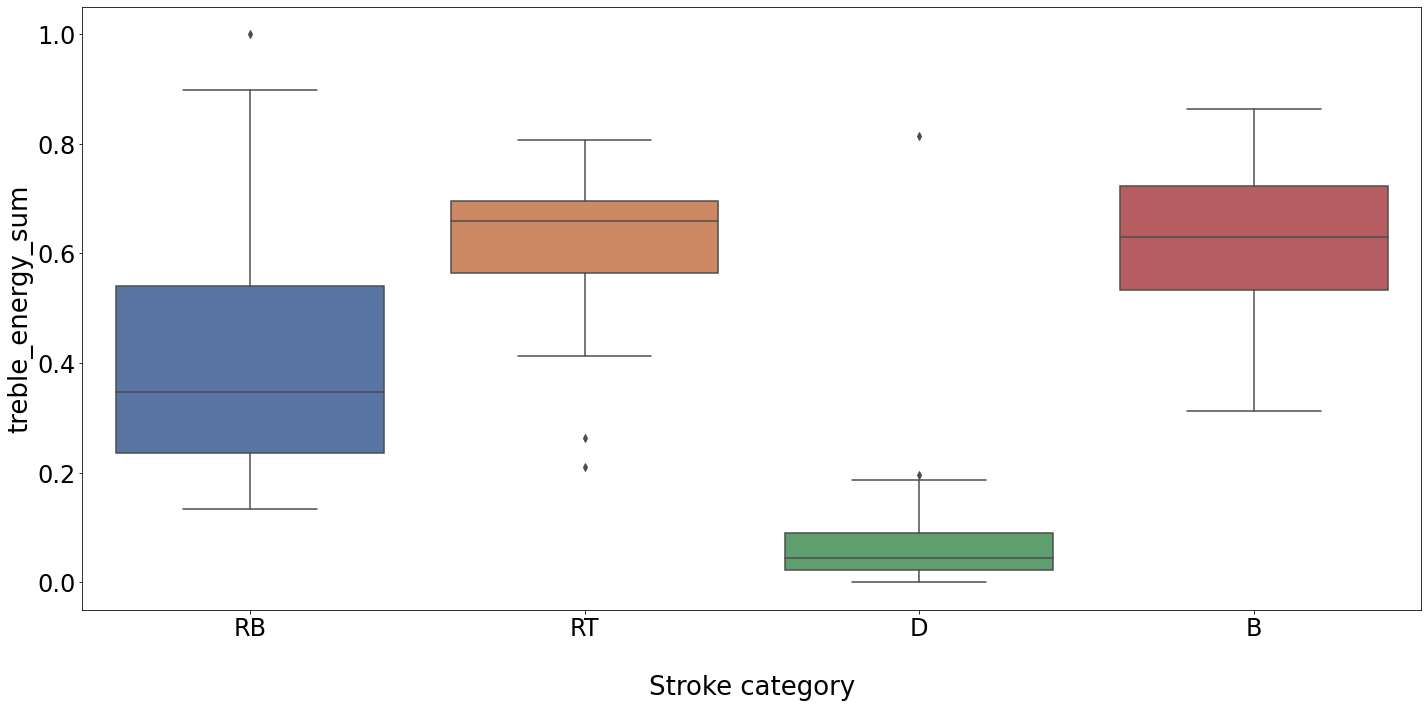

In [9]:
feature_name = 'treble_energy_sum' #can change to one of the others (see column names in data)

fig, ax = plt.subplots(1,1,sharey=True,figsize=(20,10))
sns.set()

keys=list(data.keys())

data_sub = data.loc[:,[feature_name,'stroke_category']]

#normalize feature values to lie in 0-1 range
mm_scaler = preprocessing.MinMaxScaler()
data_sub.iloc[:,:-1] = mm_scaler.fit_transform(data_sub.iloc[:,:-1])

sns.boxplot(x="stroke_category", y=feature_name, data=data_sub, ax=ax)
ax.tick_params(labelsize=24)
ax.set_xlabel('\nStroke category', fontsize=26)
ax.set_ylabel(feature_name, fontsize=26)
plt.tight_layout()